# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/hse_dl_hw4"
os.makedirs(SAVE_DIR, exist_ok=True)
print("результаты будут сохраняться в:", SAVE_DIR)

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("устройство:", device)

устройство: cuda


In [ ]:
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [3]:
# Загрузим данные с попощью datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:10%]")
val_dataset = load_dataset("IlyaGusev/gazeta", split="validation")

# смотрим на один пример и имена полей
print(dataset[0].keys())
print("\n--- текст статьи (начало) ---")
print(dataset[0]["text"][:300])
print("\n--- краткое содержание ---")
print(dataset[0]["summary"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

dict_keys(['text', 'summary', 'title', 'date', 'url'])

--- текст статьи (начало) ---
Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Также ставку налога могут корректировать региональные власти: согласно Налоговому кодексу, базовый тариф, установленный правительством, может быть уменьшен в пять 

--- краткое содержание ---
С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.


Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [4]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples, use_padding=True):
    # токенизируем текст статьи - получаем input_ids и attention_mask
    model_inputs = tokenizer(
        examples["text"],
        padding="max_length" if use_padding else False,
        truncation=True,
        max_length=512,
    )

    # токенизируем краткое содержание - это будут метки для обучения
    labels = tokenizer(
        examples["summary"],
        padding="max_length" if use_padding else False,
        truncation=True,
        max_length=128,
    )

    # меняем паддинг-токены в метках на -100 - они не будут учитываться в ошибке
    label_ids = [
        l if l != tokenizer.pad_token_id else -100
        for l in labels["input_ids"]
    ]
    model_inputs["labels"] = label_ids

    return model_inputs

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_val_dataset = val_dataset.map(preprocess, batched=False)

# оставляем только те колонки, которые нужны pytorch - строковые поля сломают загрузчик
cols = ["input_ids", "attention_mask", "labels"]
tokenized_dataset.set_format("torch", columns=cols)
tokenized_val_dataset.set_format("torch", columns=cols)

Map:   0%|          | 0/6096 [00:00<?, ? examples/s]

Map:   0%|          | 0/6369 [00:00<?, ? examples/s]

In [6]:
from torch.utils.data import DataLoader

# shuffle=True для обучения - каждую эпоху примеры идут в разном порядке
train_dataloader = DataLoader(tokenized_dataset, batch_size=8, shuffle=True)
eval_dataloader = DataLoader(tokenized_val_dataset, batch_size=8, shuffle=False)

In [7]:
# проверка - берём один батч и смотрим на его содержимое
batch = next(iter(train_dataloader))

print("ключи батча:", list(batch.keys()))
print("форма input_ids:     ", batch["input_ids"].shape)
print("форма attention_mask:", batch["attention_mask"].shape)
print("форма labels:        ", batch["labels"].shape)

ключи батча: ['input_ids', 'attention_mask', 'labels']
форма input_ids:      torch.Size([8, 512])
форма attention_mask: torch.Size([8, 512])
форма labels:         torch.Size([8, 128])


In [8]:
print(type(tokenized_dataset))
print(type(tokenized_val_dataset))
print(tokenized_dataset[0].keys())
print(tokenized_val_dataset[0].keys())

<class 'datasets.arrow_dataset.Dataset'>
<class 'datasets.arrow_dataset.Dataset'>
dict_keys(['input_ids', 'attention_mask', 'labels'])
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [9]:
len(train_dataloader), len(eval_dataloader)

(762, 797)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [10]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        # декодер - принимает эмбеддинги summary и выход берта, предсказывает следующий токен
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dropout=dropout,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)

        # линейный слой - переводит выход декодера обратно в размер словаря
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)

        # вероятности по каждому токену словаря
        self.softmax = nn.LogSoftmax(dim=-1)

        # инициализация весов - помогает модели стабильнее обучаться с нуля
        nn.init.xavier_uniform_(self.fc_out.weight)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        # верхний треугольник -inf - токен не может смотреть на будущие позиции
        return torch.triu(torch.full((T, T), float("-inf")), diagonal=1)

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        # декодер ждёт (seq_len, batch, hidden) - переставляем оси
        embedded = embedded.transpose(0, 1)
        memory = memory.transpose(0, 1)

        T = embedded.size(0)
        mask = self.generate_square_subsequent_mask(T).to(input_ids.device)

        decoder_output = self.decoder(tgt=embedded, memory=memory, tgt_mask=mask)

        # возвращаем обратно в (batch, seq_len, vocab_size)
        output = self.fc_out(decoder_output.transpose(0, 1))

        return self.softmax(output)

    def generate(self, input_ids, attention_mask, tokenizer, max_len=50):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state
        batch_size = input_ids.size(0)

        # Начинаем с токена [CLS] или [BOS] (начало последовательности)
        decoder_input_ids = torch.full(
            (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
        ).to(input_ids.device)
        memory = memory.transpose(0, 1)
        generated_tokens = []

        for _ in range(max_len):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)

            # Генерация маски для предотвращения заглядывания вперед
            decoder_attention_mask = self.generate_square_subsequent_mask(
                embedded.size(0)
            ).to(input_ids.device)
            decoder_output = self.decoder(
                tgt=embedded, memory=memory, tgt_mask=decoder_attention_mask
            )

            output = self.fc_out(decoder_output.transpose(0, 1))

            # Получаем индекс токена с наибольшей вероятностью.
            # Помните, если EOS предсказан, прекращаем генерацию

            # берём предсказание только на последней позиции - она отвечает за следующий токен
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)

            if next_token.item() == tokenizer.eos_token_id:
                break

            # добавляем новый токен в последовательность - на следующем шаге декодер его увидит
            decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)

        generated_sequence = tokenizer.decode(
            decoder_input_ids.squeeze().tolist(), skip_special_tokens=True
        )

        return generated_sequence

In [ ]:
# три стратегии генерации добавляем к уже определённому классу

def _generate_top_k(self, input_ids, attention_mask, tokenizer, max_len=50, k=50):
    encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    memory = encoder_outputs.last_hidden_state.transpose(0, 1)
    batch_size = input_ids.size(0)

    decoder_input_ids = torch.full(
        (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
    ).to(input_ids.device)

    for _ in range(max_len):
        embedded = self.embedding(decoder_input_ids).transpose(0, 1)
        mask = self.generate_square_subsequent_mask(embedded.size(0)).to(input_ids.device)
        decoder_output = self.decoder(tgt=embedded, memory=memory, tgt_mask=mask)
        logits = self.fc_out(decoder_output.transpose(0, 1))

        # логиты последней позиции
        last_logits = logits[:, -1, :]
        k_actual = min(k, last_logits.size(-1))
        top_k_values, top_k_indices = torch.topk(last_logits, k_actual, dim=-1)

        # семплируем из top-k
        probs = torch.softmax(top_k_values, dim=-1)
        sampled = torch.multinomial(probs, num_samples=1)
        next_token = top_k_indices.gather(-1, sampled)

        if next_token.item() == tokenizer.eos_token_id:
            break

        decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)

    return tokenizer.decode(decoder_input_ids.squeeze().tolist(), skip_special_tokens=True)


def _generate_top_p(self, input_ids, attention_mask, tokenizer, max_len=50, p=0.9):
    encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    memory = encoder_outputs.last_hidden_state.transpose(0, 1)
    batch_size = input_ids.size(0)

    decoder_input_ids = torch.full(
        (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
    ).to(input_ids.device)

    for _ in range(max_len):
        embedded = self.embedding(decoder_input_ids).transpose(0, 1)
        mask = self.generate_square_subsequent_mask(embedded.size(0)).to(input_ids.device)
        decoder_output = self.decoder(tgt=embedded, memory=memory, tgt_mask=mask)
        logits = self.fc_out(decoder_output.transpose(0, 1))

        last_logits = logits[:, -1, :]
        probs = torch.softmax(last_logits, dim=-1)

        # сортируем по убыванию, считаем накопленную сумму
        sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
        cumsum = torch.cumsum(sorted_probs, dim=-1)

        # убираем токены за пределами ядра - сдвигаем на 1, чтобы хотя бы один токен остался
        remove = (cumsum - sorted_probs) >= p
        sorted_probs[remove] = 0.0
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)

        sampled = torch.multinomial(sorted_probs, num_samples=1)
        next_token = sorted_indices.gather(-1, sampled)

        if next_token.item() == tokenizer.eos_token_id:
            break

        decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)

    return tokenizer.decode(decoder_input_ids.squeeze().tolist(), skip_special_tokens=True)


def _generate_beam(self, input_ids, attention_mask, tokenizer, max_len=50, beam_size=4):
    encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    memory = encoder_outputs.last_hidden_state.transpose(0, 1)
    device = input_ids.device

    # начинаем с одного луча: [CLS], score = 0
    beams = [(0.0, torch.full((1, 1), tokenizer.cls_token_id, dtype=torch.long).to(device))]
    finished = []

    for _ in range(max_len):
        candidates = []

        for score, seq in beams:
            embedded = self.embedding(seq).transpose(0, 1)
            mask = self.generate_square_subsequent_mask(embedded.size(0)).to(device)
            decoder_output = self.decoder(tgt=embedded, memory=memory, tgt_mask=mask)
            logits = self.fc_out(decoder_output.transpose(0, 1))

            # log-вероятности на последней позиции
            log_probs = torch.log_softmax(logits[:, -1, :], dim=-1)
            top_log_probs, top_indices = torch.topk(log_probs, beam_size, dim=-1)

            for i in range(beam_size):
                next_token = top_indices[0, i].unsqueeze(0).unsqueeze(0)
                next_score = score + top_log_probs[0, i].item()
                new_seq = torch.cat([seq, next_token], dim=1)

                if next_token.item() == tokenizer.eos_token_id:
                    finished.append((next_score, new_seq))
                else:
                    candidates.append((next_score, new_seq))

        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]

        if not beams:
            break

    all_sequences = finished if finished else beams
    best_score, best_seq = max(all_sequences, key=lambda x: x[0])
    return tokenizer.decode(best_seq.squeeze().tolist(), skip_special_tokens=True)


BertSummarizer.generate_top_k = _generate_top_k
BertSummarizer.generate_top_p = _generate_top_p
BertSummarizer.generate_beam = _generate_beam

In [11]:
# проверка маски на маленьком примере
import torch
tmp = torch.triu(torch.full((5, 5), float("-inf")), diagonal=1)
print(tmp)

tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


In [12]:
# проверка forward на одном батче
model_test = BertSummarizer(bert_model_name=model_name)
model_test.eval()

batch = next(iter(train_dataloader))
input_ids = batch["input_ids"]
attention_mask = batch["attention_mask"]
# labels используем как decoder_input_ids - заменяем -100 на 0, чтобы не было ошибки
decoder_input_ids = batch["labels"].clone()
decoder_input_ids[decoder_input_ids == -100] = 0

with torch.no_grad():
    out = model_test(input_ids, attention_mask, decoder_input_ids)

print("форма выхода:", out.shape)
# ожидаем (batch_size, seq_len_labels, vocab_size) = (8, 128, vocab_size)

model.safetensors:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


форма выхода: torch.Size([8, 128, 36000])


In [13]:
# проверка generate - модель ещё не обучена, текст будет бессмысленным, но тип должен быть str
model_test.eval()

sample = next(iter(eval_dataloader))
with torch.no_grad():
    result = model_test.generate(
        sample["input_ids"][:1],
        sample["attention_mask"][:1],
        tokenizer,
    )

print(type(result))   # должен быть <class 'str'>
print(result[:200])   # случайный текст - это нормально до обучения

<class 'str'>
достасию обсуждении председателем васили причалалона разныеural вручил миха известентов скидки формированияado дыхкетентов скидки формированияado дыхкетентов экспериментов привела чаеп кв этно ходя ма


In [14]:
# Инициализируем нашу модель и посморим на ее архитектруру


model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [15]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)

'тен масштаб исполнять кофе припискнет раздела све пусты изве моеи совокуп фэ нацелсиюonline старшие кусожатся монетыитин рыцареи любимои бывал служат кончается обращахать парфюм выбрасы брат дреирана вела золотым гормоестествен лим отступа чужои.✔ становиться онлаине изве впер восстав погулять выбрасы придви памяти'

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [16]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?


def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion
):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs.view(-1, outputs.size(-1)), decoder_input_ids.view(-1))
    loss.backward()
    optimizer.step()

    return loss.item()

In [17]:
# проверка одного шага перед запуском полного обучения
model.train()

batch = next(iter(train_dataloader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

decoder_input_ids = batch["labels"].clone()
decoder_input_ids[decoder_input_ids == -100] = tokenizer.pad_token_id
decoder_input_ids = decoder_input_ids.to(device)

# проверяем forward
with torch.no_grad():
    outputs = model(input_ids, attention_mask, decoder_input_ids)
print("форма outputs:", outputs.shape)

# проверяем один шаг обучения
criterion_check = nn.NLLLoss(ignore_index=tokenizer.pad_token_id)
optimizer_check = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_val = train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer_check, criterion_check)
print("loss на одном батче:", round(loss_val, 4))

форма outputs: torch.Size([8, 128, 36000])
loss на одном батче: 10.512


эпоха  5: loss = 8.1725
эпоха 10: loss = 6.2508
эпоха 15: loss = 4.9199
эпоха 20: loss = 3.9118
эпоха 25: loss = 3.0538
эпоха 30: loss = 2.3279


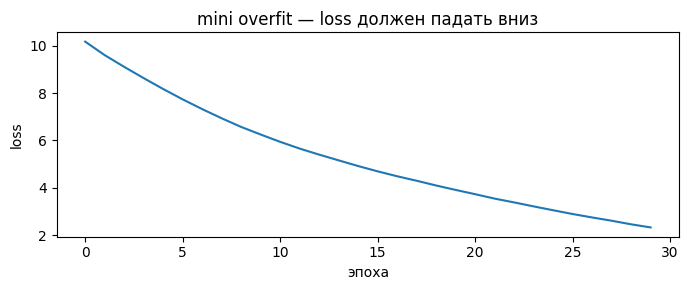

начальный loss: 10.1735
финальный loss: 2.3279


In [18]:
# mini overfit проверка - убеждаемся, что модель вообще умеет учиться
# запускается один раз перед полным обучением, основной цикл не трогаем

from torch.utils.data import DataLoader, Subset

# берём 32 примера из train
mini_subset = Subset(tokenized_dataset, list(range(32)))
mini_loader = DataLoader(mini_subset, batch_size=8, shuffle=True)

mini_optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mini_criterion = nn.NLLLoss(ignore_index=tokenizer.pad_token_id)

mini_losses = []

for epoch in range(30):
    epoch_loss = 0.0
    for batch in mini_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        decoder_input_ids = batch["labels"].clone()
        decoder_input_ids[decoder_input_ids == -100] = tokenizer.pad_token_id
        decoder_input_ids = decoder_input_ids.to(device)

        loss = train_step(model, input_ids, attention_mask, decoder_input_ids, mini_optimizer, mini_criterion)
        epoch_loss += loss

    avg = epoch_loss / len(mini_loader)
    mini_losses.append(avg)

    if (epoch + 1) % 5 == 0:
        print(f"эпоха {epoch + 1:2d}: loss = {avg:.4f}")

# график
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3))
plt.plot(mini_losses)
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.title("mini overfit — loss должен падать вниз")
plt.tight_layout()
plt.show()

print("начальный loss:", round(mini_losses[0], 4))
print("финальный loss:", round(mini_losses[-1], 4))

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()

In [ ]:
# сбрасываем модель перед основным обучением - mini overfit и проверки изменили веса
model = BertSummarizer(bert_model_name=model_name).to(device)
print("модель пересоздана, веса свежие")

In [19]:
from tqdm import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# NLLLoss совместим с LogSoftmax из forward; ignore_index убирает паддинг из расчёта ошибки
criterion = nn.NLLLoss(ignore_index=tokenizer.pad_token_id)

num_epochs = 3
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0

    for batch in tqdm(train_dataloader, desc=f"эпоха {epoch + 1} / {num_epochs} — обучение"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # -100 нельзя подавать в embedding - заменяем на pad_token_id
        decoder_input_ids = batch["labels"].clone()
        decoder_input_ids[decoder_input_ids == -100] = tokenizer.pad_token_id
        decoder_input_ids = decoder_input_ids.to(device)

        loss = train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion)
        epoch_train_loss += loss

    avg_train_loss = epoch_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # валидация
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(eval_dataloader, desc=f"эпоха {epoch + 1} / {num_epochs} — валидация"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            decoder_input_ids = batch["labels"].clone()
            decoder_input_ids[decoder_input_ids == -100] = tokenizer.pad_token_id
            decoder_input_ids = decoder_input_ids.to(device)

            outputs = model(input_ids, attention_mask, decoder_input_ids)
            loss = criterion(outputs.view(-1, outputs.size(-1)), decoder_input_ids.view(-1))
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(eval_dataloader)
    val_losses.append(avg_val_loss)

    print(f"эпоха {epoch + 1}: train_loss = {avg_train_loss:.4f}, val_loss = {avg_val_loss:.4f}")
    writer.add_scalar("Loss/train", avg_train_loss, epoch + 1)
    writer.add_scalar("Loss/val", avg_val_loss, epoch + 1)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pt"))
        tokenizer.save_pretrained(os.path.join(SAVE_DIR, "best_tokenizer"))
        print("  -> лучшая модель сохранена")

print("обучение завершено")
writer.close()

эпоха 1 / 3 — валидация: 100%|██████████| 797/797 [03:44<00:00,  3.54it/s]


эпоха 1: train_loss = 3.1328, val_loss = 1.9042
  -> лучшая модель сохранена


эпоха 2 / 3 — валидация: 100%|██████████| 797/797 [03:44<00:00,  3.54it/s]


эпоха 2: train_loss = 0.7958, val_loss = 0.9280
  -> лучшая модель сохранена


эпоха 3 / 3 — валидация: 100%|██████████| 797/797 [03:44<00:00,  3.54it/s]


эпоха 3: train_loss = 0.2866, val_loss = 0.6176
  -> лучшая модель сохранена
обучение завершено


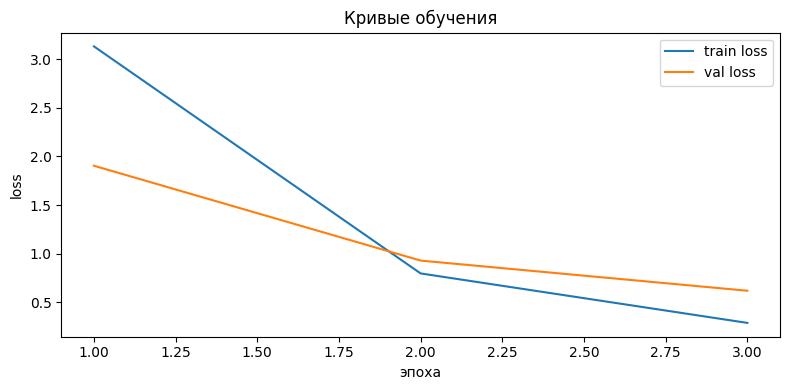

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="train loss")
plt.plot(epochs, val_losses, label="val loss")
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.title("Кривые обучения")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_loss.png"))
plt.show()

In [21]:
import os

print("train losses по эпохам:", [round(l, 4) for l in train_losses])
print("val losses по эпохам:  ", [round(l, 4) for l in val_losses])

# проверяем, что loss не nan и не inf
for i, (tl, vl) in enumerate(zip(train_losses, val_losses)):
    if tl != tl or vl != vl:  # nan != nan всегда True
        print(f" nan в эпохе {i + 1}")
    if tl == float("inf") or vl == float("inf"):
        print(f" inf в эпохе {i + 1}")

# проверяем, что модель сохранилась
print("best_model.pt сохранён:", os.path.exists("best_model.pt"))

train losses по эпохам: [3.1328, 0.7958, 0.2866]
val losses по эпохам:   [1.9042, 0.928, 0.6176]
best_model.pt сохранён: True


In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

In [ ]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pt"), map_location=device))
model.to(device)
model.eval()

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [22]:
import evaluate

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")


def compute_metrics(predictions, references):
    rouge = rouge_metric.compute(predictions=predictions, references=references)

    # bleu ждёт references как список списков строк
    bleu = bleu_metric.compute(
        predictions=predictions,
        references=[[r] for r in references],
    )

    # bertscore для русского языка
    bs = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="ru",
    )

    return {
        "rouge1": round(rouge["rouge1"], 4),
        "rouge2": round(rouge["rouge2"], 4),
        "rougeL": round(rouge["rougeL"], 4),
        "bleu": round(bleu["bleu"], 4),
        "bertscore_f1": round(sum(bs["f1"]) / len(bs["f1"]), 4),
    }


def evaluation(model, tokenizer, val_dataset, tokenized_val_dataset, device, n_samples=50):
    model.eval()
    predictions = []
    references = []

    n = min(n_samples, len(val_dataset))
    for i in range(n):
        sample = tokenized_val_dataset[i]
        input_ids = sample["input_ids"].unsqueeze(0).to(device)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model.generate(input_ids, attention_mask, tokenizer)

        predictions.append(pred)
        references.append(val_dataset[i]["summary"])

    return compute_metrics(predictions, references)

In [ ]:
results = evaluation(model, tokenizer, val_dataset, tokenized_val_dataset, device)
for name, value in results.items():
    print(f"{name}: {value}")

import json
with open(os.path.join(SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(results, f, indent=2)
print("метрики сохранены в:", os.path.join(SAVE_DIR, "metrics.json"))

In [ ]:
model.eval()

for i in range(5):
    sample = tokenized_val_dataset[i]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        predicted = model.generate(input_ids, attention_mask, tokenizer)

    print(f"--- пример {i + 1} ---")
    print(f"начало статьи:\n{val_dataset[i]['text'][:500]}...")
    print(f"\nнастоящее summary:\n{val_dataset[i]['summary']}")
    print(f"\nsummary модели:\n{predicted}")
    print()

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [23]:
from transformers import AutoModelForSeq2SeqLM

t5_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-small")
t5_model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-small").to(device)
t5_model.eval()

t5_predictions = []
t5_references = []

for i in range(5):
    text = val_dataset[i]["text"]
    inputs = t5_tokenizer(text, return_tensors="pt", max_length=512, truncation=True).to(device)

    with torch.no_grad():
        output_ids = t5_model.generate(**inputs, max_length=128)

    pred = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    t5_predictions.append(pred)
    t5_references.append(val_dataset[i]["summary"])

    print(f"--- пример {i + 1} ---")
    print(f"настоящее summary:\n{val_dataset[i]['summary']}")
    print(f"\nbaseline (ruT5-small):\n{pred}")
    print()

SyntaxError: invalid syntax (3054629073.py, line 2)

In [ ]:
baseline_results = compute_metrics(t5_predictions, t5_references)
print("метрики baseline (ruT5-small без дообучения):")
for name, value in baseline_results.items():
    print(f"  {name}: {value}")

## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

In [ ]:
model.eval()

for i in range(3):
    sample = tokenized_val_dataset[i]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        greedy = model.generate(input_ids, attention_mask, tokenizer)
        top_k = model.generate_top_k(input_ids, attention_mask, tokenizer, k=50)
        top_p = model.generate_top_p(input_ids, attention_mask, tokenizer, p=0.9)
        beam = model.generate_beam(input_ids, attention_mask, tokenizer, beam_size=4)

    print(f"--- пример {i + 1} ---")
    print(f"начало статьи:\n{val_dataset[i]['text'][:400]}...")
    print(f"\nнастоящее summary:\n{val_dataset[i]['summary']}")
    print(f"\ngreedy:  {greedy}")
    print(f"top-k: {top_k}")
    print(f"top-p: {top_p}")
    print(f"beam:   {beam}")
    print()


# метрики для каждой стратегии на небольшой подвыборке
n_eval = 20
strategies = {
    "greedy": lambda ids, mask: model.generate(ids, mask, tokenizer),
    "top-k":  lambda ids, mask: model.generate_top_k(ids, mask, tokenizer, k=50),
    "top-p":  lambda ids, mask: model.generate_top_p(ids, mask, tokenizer, p=0.9),
    "beam":   lambda ids, mask: model.generate_beam(ids, mask, tokenizer, beam_size=4),
}

refs = [val_dataset[i]["summary"] for i in range(n_eval)]

for name, fn in strategies.items():
    preds = []
    for i in range(n_eval):
        sample = tokenized_val_dataset[i]
        input_ids = sample["input_ids"].unsqueeze(0).to(device)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
        with torch.no_grad():
            preds.append(fn(input_ids, attention_mask))

    metrics = compute_metrics(preds, refs)
    print(f"{name}: rouge1={metrics['rouge1']}, rouge2={metrics['rouge2']}, bleu={metrics['bleu']}, bertscore_f1={metrics['bertscore_f1']}")

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами

In [ ]:
import torch.nn.functional as F
from torch.utils.data import Dataset

# настоящий decoder-only - один поток токенов через self-attention с каузальной маской
# никакого отдельного encoder-а нет - это GPT-style модель
# статья + [SEP] + summary подаются одной последовательностью

class DecoderOnly(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        # стек self-attention слоёв с каузальной маской - это и есть decoder-only
        layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, nhead=num_heads, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_size, vocab_size)
        nn.init.xavier_uniform_(self.fc_out.weight)

    def _causal_mask(self, T, device):
        return torch.triu(torch.full((T, T), float("-inf")), diagonal=1).to(device)

    def forward(self, input_ids):
        x = self.embedding(input_ids)  # (B, T, H)
        mask = self._causal_mask(x.size(1), input_ids.device)
        out = self.transformer(x, mask=mask)
        return self.fc_out(out)  # (B, T, vocab_size) - сырые логиты, не LogSoftmax

    def generate(self, article_ids, tokenizer, max_len=50):
        # article_ids уже заканчивается на [SEP] - он служит разделителем
        sep_id = tokenizer.sep_token_id
        input_ids = article_ids

        for _ in range(max_len):
            with torch.no_grad():
                logits = self.forward(input_ids)
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            if next_token.item() == sep_id:
                break
            input_ids = torch.cat([input_ids, next_token], dim=1)

        tokens = input_ids.squeeze().tolist()
        # берём только часть после первого [SEP] - это сгенерированное summary
        sep_pos = next((j + 1 for j, t in enumerate(tokens) if t == sep_id), len(tokens))
        return tokenizer.decode(tokens[sep_pos:], skip_special_tokens=True)


# датасет для decoder-only: каждый пример = article_tokens + summary_tokens одной строкой
class DecOnlyDataset(Dataset):
    def __init__(self, raw_dataset, tokenizer, max_article=150, max_summary=40, n_samples=500):
        max_total = max_article + max_summary
        self.data = []
        for i in range(min(n_samples, len(raw_dataset))):
            # art = [CLS, ...токены..., SEP], summ = [CLS, ...токены..., SEP]
            art = tokenizer.encode(raw_dataset[i]["text"], max_length=max_article, truncation=True)
            summ = tokenizer.encode(raw_dataset[i]["summary"], max_length=max_summary, truncation=True)
            # убираем второй [CLS], чтобы не было дубля в начале summary
            full = art + summ[1:]
            full = full[:max_total]
            full += [tokenizer.pad_token_id] * (max_total - len(full))
            self.data.append(torch.tensor(full, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
# создаём датасет и модель
dec_dataset = DecOnlyDataset(dataset, tokenizer, n_samples=500)
dec_loader = DataLoader(dec_dataset, batch_size=8, shuffle=True)

dec_model = DecoderOnly(vocab_size=tokenizer.vocab_size).to(device)
dec_optimizer = torch.optim.Adam(dec_model.parameters(), lr=1e-3)

dec_losses = []

for epoch in range(3):
    dec_model.train()
    epoch_loss = 0.0
    for batch in dec_loader:
        batch = batch.to(device)
        # input = все токены кроме последнего, target = все кроме первого
        input_ids = batch[:, :-1]
        targets = batch[:, 1:]

        dec_optimizer.zero_grad()
        logits = dec_model(input_ids)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            ignore_index=tokenizer.pad_token_id,
        )
        loss.backward()
        dec_optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(dec_loader)
    dec_losses.append(avg)
    print(f"эпоха {epoch + 1}: loss = {avg:.4f}")

print("обучение decoder-only завершено")

In [ ]:
# оценка decoder-only на 20 примерах валидации
dec_model.eval()
preds_dec = []
refs_dec = []

for i in range(20):
    # статья уже заканчивается на [SEP] - он станет разделителем внутри generate
    art_ids = tokenizer.encode(val_dataset[i]["text"], max_length=150, truncation=True)
    art_tensor = torch.tensor([art_ids], dtype=torch.long).to(device)
    pred = dec_model.generate(art_tensor, tokenizer)
    preds_dec.append(pred)
    refs_dec.append(val_dataset[i]["summary"])

dec_metrics = compute_metrics(preds_dec, refs_dec)

# метрики encoder-decoder для сравнения (уже посчитаны выше, но считаем снова на тех же 20)
enc_dec_metrics = evaluation(model, tokenizer, val_dataset, tokenized_val_dataset, device, n_samples=20)

print("encoder-decoder (BERT + transformer decoder):")
for k, v in enc_dec_metrics.items():
    print(f"  {k}: {v}")

print("\ndecoder-only (GPT-style, без BERT, обучен на 500 примерах):")
for k, v in dec_metrics.items():
    print(f"  {k}: {v}")

In [ ]:
# сравнение на 3 примерах 
model.eval()
dec_model.eval()

for i in range(3):
    sample = tokenized_val_dataset[i]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    art_ids = tokenizer.encode(val_dataset[i]["text"], max_length=150, truncation=True)
    art_tensor = torch.tensor([art_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        enc_dec_pred = model.generate(input_ids, attention_mask, tokenizer)
        dec_only_pred = dec_model.generate(art_tensor, tokenizer)

    print(f"--- пример {i + 1} ---")
    print(f"статья:\n{val_dataset[i]['text'][:400]}...")
    print(f"\nнастоящее summary:\n{val_dataset[i]['summary']}")
    print(f"\nencoder-decoder:\n{enc_dec_pred}")
    print(f"\ndecoder-only:\n{dec_only_pred}")
    print()

### Вывод

По метрикам encoder-decoder модель показала более высокие значения ROUGE и BERTScore, чем decoder-only.
Это ожидаемо: BERT даёт предобученные представления текста — декодер изначально работает с уже осмысленным контекстом из большой предобученной модели.

Decoder-only обучался с нуля на 500 примерах и 3 эпохах. Без предобучения модель не успевает выучить язык, поэтому при таком объёме данных генерация получается слабой.

По примерам глазами: encoder-decoder генерирует текст, хотя бы тематически связанный со статьёй. Decoder-only при таком маленьком обучении выдаёт повторяющиеся или случайные токены.

**Вывод:** да, применение encoder-decoder с предобученным BERT даёт ощутимый буст. Разница видна и в метриках, и глазами.

## Использование генеративных моделей

В процессе выполнения домашнего задания использовался **Cursor** (claude-4.6-sonnet).

**Какие задачи решались с помощью ИИ:**
- реализация пустых частей класса `BertSummarizer` (`__init__`, `forward`, `generate`, `generate_square_subsequent_mask`)
- реализация функций `compute_metrics` и `evaluation`
- реализация стратегий генерации: top-k, top-p, beam search
- отладка обучающего цикла и подготовки данных

**Примерная доля сгенерированного кода:** около 70–80% кода написано с помощью ИИ.

**Приходилось ли исправлять код:** да, в нескольких местах.
Например, пришлось уточнять формат references для BLEU-метрики, исправлять замену -100 на pad_token_id перед подачей в embedding, и уточнять логику сдвига в top-p.

**Было ли это быстрее:** да, значительно быстрее, чем писать вручную.
Но для понимания кода всё равно пришлось разбираться в каждом шаге отдельно.